In [9]:
import numpy as np
import matplotlib.pyplot as plt

try:
    from scipy.signal import convolve2d
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False
    print("[WARN] scipy 不可用，Project 2 的空间卷积部分将无法运行。")


def show_images(imgs, titles, cmap='gray', figsize=(15, 4)):
    plt.figure(figsize=figsize)
    for i, (im, t) in enumerate(zip(imgs, titles), 1):
        plt.subplot(1, len(imgs), i)
        plt.imshow(im, cmap=cmap)
        plt.title(t)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def fft2c(img):
    return np.fft.fftshift(np.fft.fft2(img))


def ifft2c(F):
    return np.real(np.fft.ifft2(np.fft.ifftshift(F)))


def normalize01(x):
    x = x - x.min()
    d = x.max() - x.min() + 1e-12
    return x / d

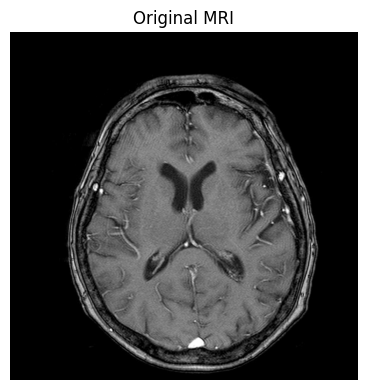

Shape: (800, 800) Range: (np.float64(0.0), np.float64(0.9999999999999961))


In [2]:
# 读取原始 MRI 数据（Project 1 / Project 2）
img = np.load(r"D:\coding\DIP_project\LAB3\lab3.npy").astype(np.float64)

if img.ndim == 3:
    img = img[img.shape[0] // 2]

img = normalize01(img)
show_images([img], ["Original MRI"], figsize=(4, 4))
print("Shape:", img.shape, "Range:", (img.min(), img.max()))

## Project 1: Ringing Effect

实现三种低通滤波器（`D0 = 30`）：Ideal、Butterworth（`n=6`）、Gaussian，并比较振铃效应。

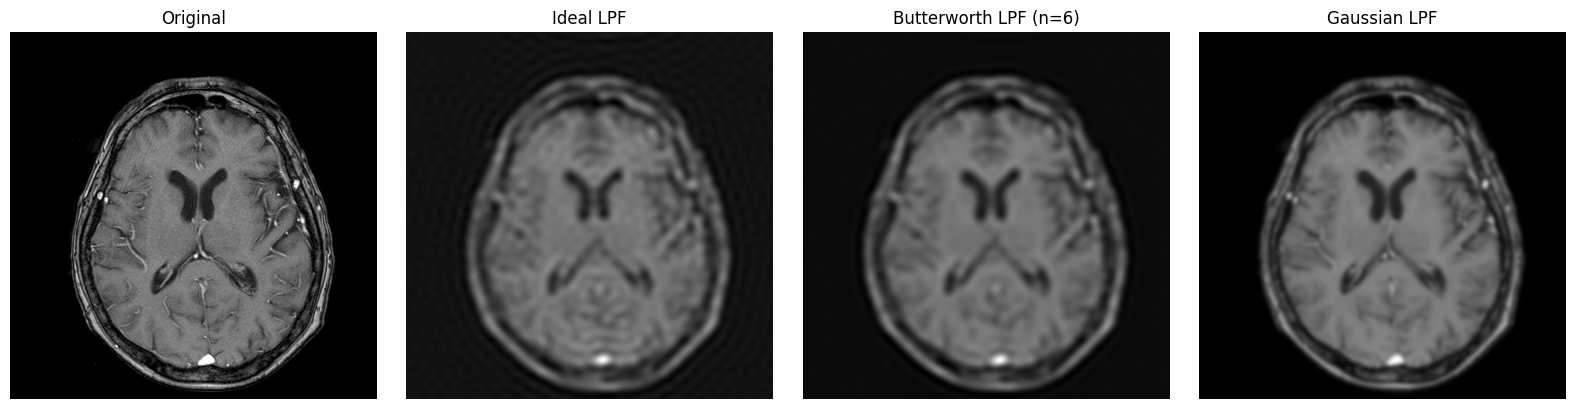

In [3]:
def distance_grid(shape):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    cx, cy = w // 2, h // 2
    return np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)


def ideal_lpf(shape, D0):
    D = distance_grid(shape)
    return (D <= D0).astype(np.float64)


def butterworth_lpf(shape, D0, n=6):
    D = distance_grid(shape)
    return 1.0 / (1.0 + (D / (D0 + 1e-12)) ** (2 * n))


def gaussian_lpf(shape, D0):
    D = distance_grid(shape)
    return np.exp(-(D ** 2) / (2 * (D0 ** 2)))


D0 = 30
F = fft2c(img)
H_i = ideal_lpf(img.shape, D0)
H_b = butterworth_lpf(img.shape, D0, n=6)
H_g = gaussian_lpf(img.shape, D0)

out_i = normalize01(ifft2c(F * H_i))
out_b = normalize01(ifft2c(F * H_b))
out_g = normalize01(ifft2c(F * H_g))

show_images(
    [img, out_i, out_b, out_g],
    ["Original", "Ideal LPF", "Butterworth LPF (n=6)", "Gaussian LPF"],
    figsize=(16, 4),
)

### Project 1 结果分析

- Ideal 低通在截止频率处存在突变，空间域对应 sinc 型脉冲响应，会在边缘附近产生最明显的振铃。
- Butterworth 低通（n=6）过渡带比 Ideal 平滑，振铃减弱，但边缘附近仍可见轻微波纹。
- Gaussian 低通频域与空间域都最平滑，几乎不出现明显振铃，但会带来更均匀的高频细节损失。
- 三者共同体现了“截止越陡、振铃越强；过渡越平滑、振铃越弱”的典型规律。

## Project 2: Identical Filter

实现空间域 Gaussian 低通（`sigma=1,3,5`）及其对应频域滤波，另外实现 Laplacian 高通（4 邻域与 8 邻域）并比较结果。

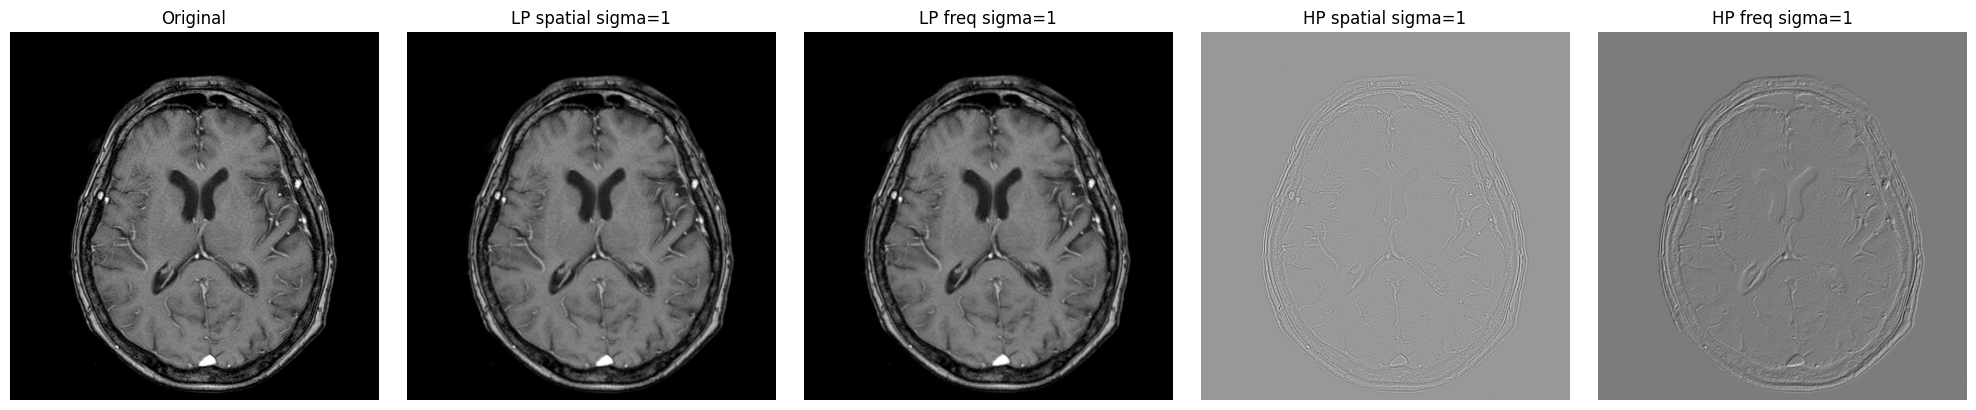

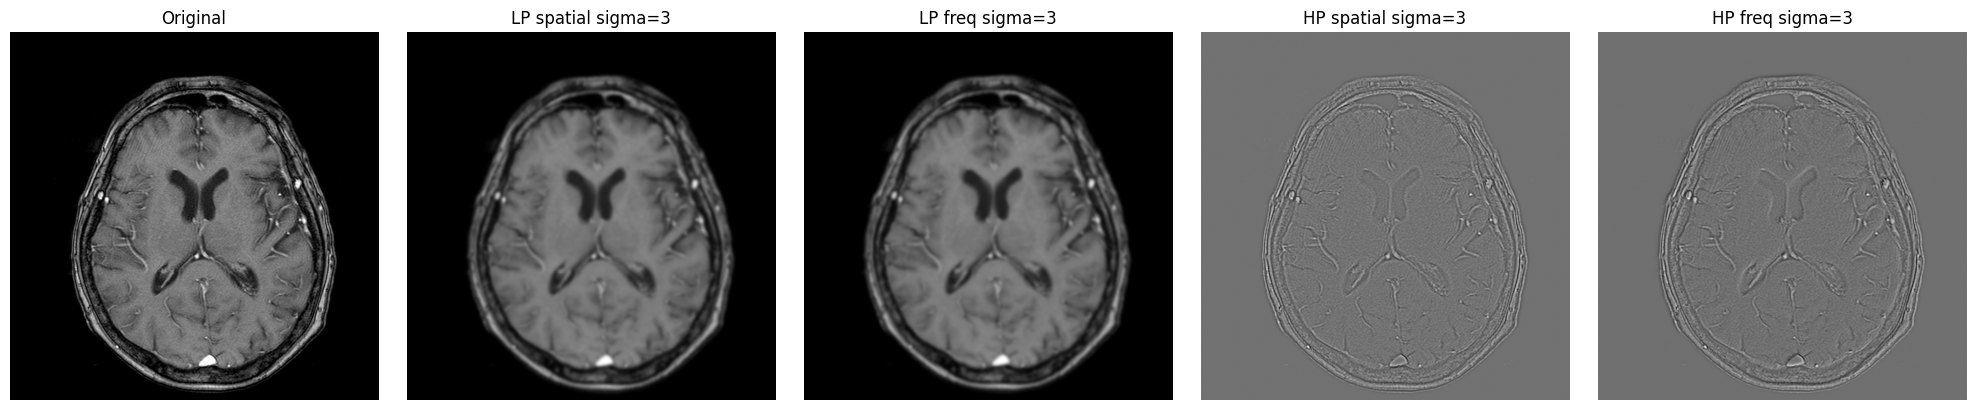

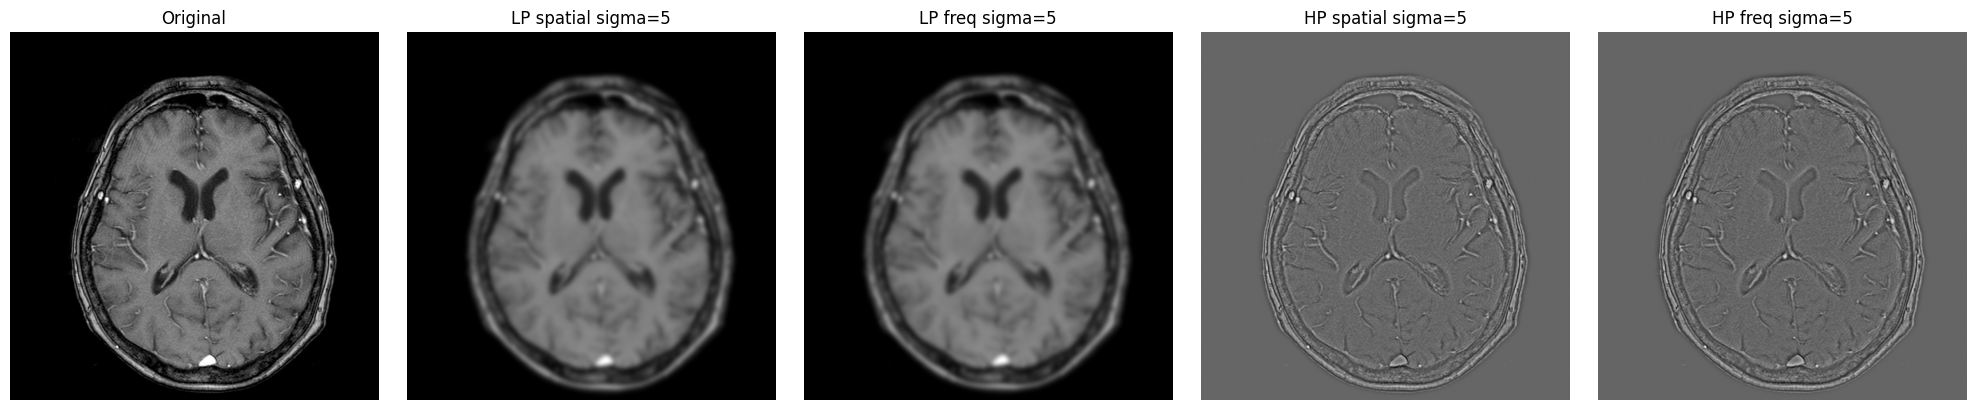

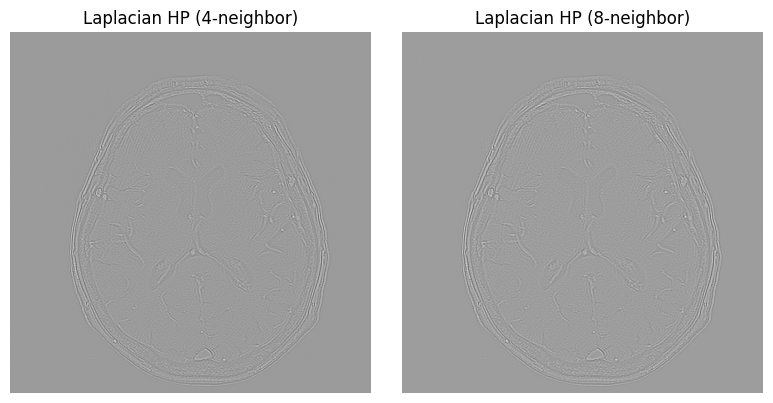

In [4]:
def gaussian_kernel(ksize, sigma):
    ax = np.arange(-(ksize // 2), ksize // 2 + 1)
    X, Y = np.meshgrid(ax, ax)
    K = np.exp(-(X**2 + Y**2) / (2 * sigma**2))
    K /= K.sum() + 1e-12
    return K


def psf2otf(psf, shape):
    out = np.zeros(shape, dtype=np.float64)
    kh, kw = psf.shape
    out[:kh, :kw] = psf
    out = np.roll(out, -kh // 2, axis=0)
    out = np.roll(out, -kw // 2, axis=1)
    return np.fft.fft2(out)


if not SCIPY_OK:
    print("当前环境无 scipy，建议安装 scipy 后再运行本单元。")
else:
    sigma_list = [1, 3, 5]
    for s in sigma_list:
        ksize = int(2 * np.ceil(3 * s) + 1)
        K = gaussian_kernel(ksize, s)

        lp_spatial = convolve2d(img, K, mode='same', boundary='symm')
        hp_spatial = img - lp_spatial

        H = psf2otf(K, img.shape)
        F0 = np.fft.fft2(img)
        lp_freq = np.real(np.fft.ifft2(F0 * H))
        hp_freq = img - lp_freq

        show_images(
            [img, normalize01(lp_spatial), normalize01(lp_freq), normalize01(hp_spatial), normalize01(hp_freq)],
            [f"Original", f"LP spatial sigma={s}", f"LP freq sigma={s}", f"HP spatial sigma={s}", f"HP freq sigma={s}"],
            figsize=(20, 4),
        )

    lap4 = np.array([[0, -1, 0],
                     [-1, 4, -1],
                     [0, -1, 0]], dtype=np.float64)

    lap8 = np.array([[-1, -1, -1],
                     [-1, 8, -1],
                     [-1, -1, -1]], dtype=np.float64)

    hp_lap4 = convolve2d(img, lap4, mode='same', boundary='symm')
    hp_lap8 = convolve2d(img, lap8, mode='same', boundary='symm')

    show_images(
        [normalize01(hp_lap4), normalize01(hp_lap8)],
        ["Laplacian HP (4-neighbor)", "Laplacian HP (8-neighbor)"],
        figsize=(8, 4),
    )

### Project 2 结果分析

- 对同一 Gaussian 核，**空间域卷积**与**频域相乘**结果基本一致，仅在边界处理与数值精度处有轻微差异，验证了卷积定理。
- 随着 `sigma` 增大，低通效果增强，图像更平滑；对应高通结果中，细节和噪声也会同时被强调。
- 用原图减去高斯低通得到高通时，背景变化不大、看上去比较平，边缘和纹理会更显眼；改 σ 就能调节这种强调的强弱。
- Laplacian 高通对二阶变化更敏感，边缘响应更强；其中 **8 邻域**通常比 **4 邻域**响应更强、更锐利，但噪声放大也更明显。

## Project 3: Notch Filter

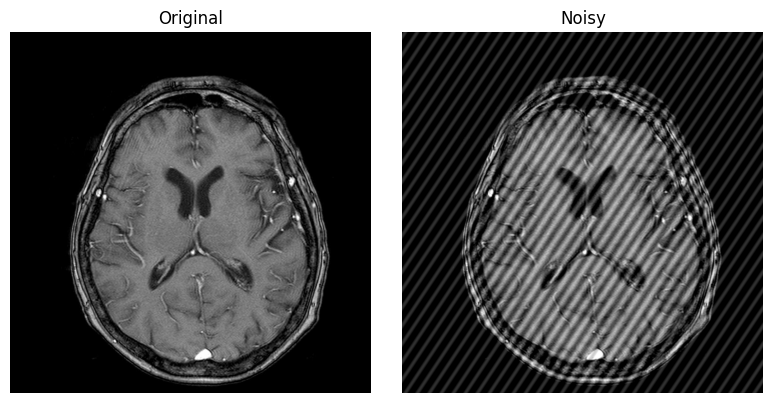

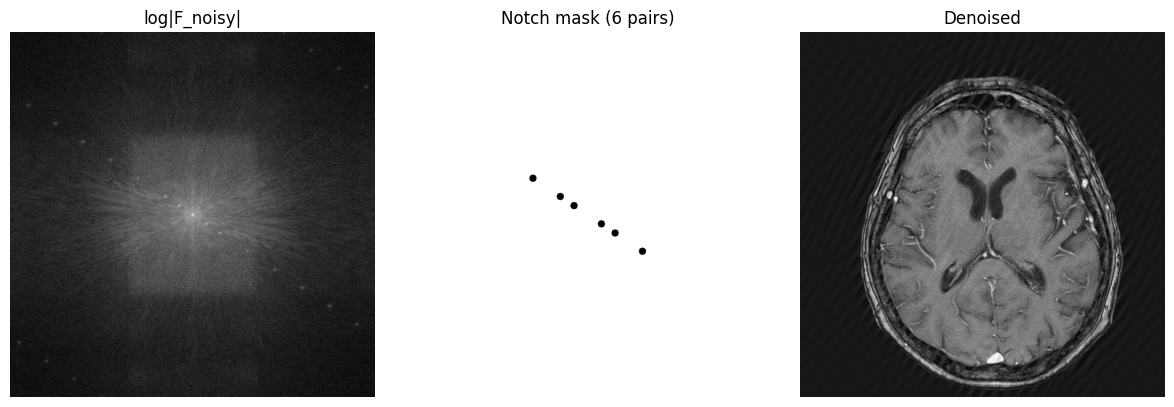

peaks: [(np.int64(380), np.int64(370)), (np.int64(420), np.int64(430)), (np.int64(360), np.int64(340)), (np.int64(440), np.int64(460)), (np.int64(480), np.int64(520)), (np.int64(320), np.int64(280))]
pairs: [((np.int64(380), np.int64(370)), (np.int64(420), np.int64(430))), ((np.int64(420), np.int64(430)), (np.int64(380), np.int64(370))), ((np.int64(360), np.int64(340)), (np.int64(440), np.int64(460))), ((np.int64(440), np.int64(460)), (np.int64(360), np.int64(340))), ((np.int64(480), np.int64(520)), (np.int64(320), np.int64(280))), ((np.int64(320), np.int64(280)), (np.int64(480), np.int64(520)))]


In [6]:
# 读取含噪 MRI 数据
noisy_img = np.load(r"D:\coding\DIP_project\LAB3\lab3_noise.npy").astype(np.float64)

if noisy_img.ndim == 3:
    noisy_img = noisy_img[noisy_img.shape[0] // 2]

noisy_img = normalize01(noisy_img)
show_images([img, noisy_img], ["Original", "Noisy"], figsize=(8, 4))


def notch_reject(shape, center_pairs, r=6):
    h, w = shape
    Y, X = np.ogrid[:h, :w]
    H = np.ones(shape, dtype=np.float64)
    for (cy1, cx1), (cy2, cx2) in center_pairs:
        D1 = np.sqrt((X - cx1) ** 2 + (Y - cy1) ** 2)
        D2 = np.sqrt((X - cx2) ** 2 + (Y - cy2) ** 2)
        H[(D1 <= r) | (D2 <= r)] = 0
    return H


Fn = fft2c(noisy_img)
mag = np.log1p(np.abs(Fn))

h, w = noisy_img.shape
cy, cx = h // 2, w // 2

# 1) 屏蔽中心低频
search = mag.copy()
rr = 25
search[cy-rr:cy+rr+1, cx-rr:cx+rr+1] = 0

# 2) 找 K 个峰（每找到一个就抹掉附近，避免重复）
K = 6
suppress = 10
peaks = []

for _ in range(K):
    py, px = np.unravel_index(np.argmax(search), search.shape)
    peaks.append((py, px))

    Y, X = np.ogrid[:h, :w]
    D = np.sqrt((X - px) ** 2 + (Y - py) ** 2)
    search[D <= suppress] = 0

# 3) 构造对称峰对
center_pairs = []
for py, px in peaks:
    qy, qx = 2 * cy - py, 2 * cx - px
    center_pairs.append(((py, px), (qy, qx)))

# 4) 构造多对 notch mask 并滤波
r = 8
H = notch_reject(noisy_img.shape, center_pairs, r=r)
out = normalize01(ifft2c(Fn * H))

show_images(
    [mag, H, out],
    ["log|F_noisy|", f"Notch mask ({K} pairs)", "Denoised"],
    figsize=(12, 4)
)

print("peaks:", peaks)
print("pairs:", center_pairs)

### Project 3 结果分析

- 本代码先对 `log|F_noisy|` 做中心屏蔽（`rr=25`），再以“选峰-抑制邻域”的方式自动寻找 `K=6` 个噪声峰（`suppress=10`），可避免重复选中同一团峰。
- 对每个峰按频谱中心构造共轭对称点，形成 `center_pairs`，再使用圆形硬陷波器（`r=8`）同时压制一对频率分量，符合周期条纹噪声的频域特征。
- 该实现属于理想型硬陷波，抑制能力强，条纹去除更直接；但截止较陡，可能带来轻微细节损失或局部伪影。
- 从结果看，斜向周期条纹明显减弱，主体脑组织轮廓仍可辨识，说明当前参数在去噪强度与结构保真之间达到可接受平衡。